<a href="https://colab.research.google.com/github/giuliabugatti09/PPE-Detector-CNN-/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Project: PPE Detection using Convolutional Neural Networks (CNN)
## Goal: Build a classification model from scratch to detect "Helmet" vs "Head".



## 1. Introduction & Environment Setup

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import zipfile
from sklearn.model_selection import train_test_split

# Keras Components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- DATASET UNZIPPING ---
dataset_dir = "../dataset"
zip_filename = R"C:\Users\Fran\cnn\PPE-Detector-CNN-\data\Hard Hat Workers.v2-raw.multiclass.zip"

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print(f"✅ Success: Dataset extracted to '{dataset_dir}'")
else:
    print(f"⚠️ Warning: {zip_filename} not found. Ensure the zip is in the root folder.")

✅ Success: Dataset extracted to '../dataset'


## 2. Data Preparation (CSV to Flow)

In [2]:
# Path to the training metadata
train_csv_path = os.path.join(dataset_dir, "train", "_classes.csv")
train_img_dir = os.path.join(dataset_dir, "train")

# Load and clean the CSV
train_df = pd.read_csv(train_csv_path)
train_df.columns = [c.strip() for c in train_df.columns] # Remove white spaces

# Conversion for Binary Classification:
# We need to map the one-hot columns back to a single string label for flow_from_dataframe
def get_label(row):
    if row['helmet'] == 1: return 'helmet'
    return 'head'

train_df['label'] = train_df.apply(get_label, axis=1)
# Pega todas as cabeças
df_heads = train_df[train_df['label'] == 'head']
# Pega apenas a mesma quantidade de capacetes (ou um pouco mais)
df_helmets = train_df[train_df['label'] == 'helmet'].sample(n=len(df_heads) * 2, random_state=42)

# Junta os dois em um novo dataframe equilibrado
train_df_balanced = pd.concat([df_heads, df_helmets]).sample(frac=1).reset_index(drop=True)

# Use o 'train_df_balanced' no seu flow_from_dataframe
# Display first few rows to confirm
print("--- Training Data Sample ---")
display(train_df[['filename', 'label']].head())

--- Training Data Sample ---


,filename,label
0,003626_jpg.rf.0024e8fc3c8c3f411962ca8dab7b8e92...,helmet
1,004434_jpg.rf.002a70f061745a217db4320ae7b402a7...,head
2,004858_jpg.rf.002ab521984d81c7400faa6f916f5a01...,head
3,002310_jpg.rf.0008cd4590d2edb0e1447329236d9c11...,helmet
4,004785_jpg.rf.002ffb29898b3cba483a76e8b73d91a8...,helmet


## 3. Data Augmentation & Generators

In [3]:
# Parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training Generator with Strong Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Automatically splits 20% for validation
)

# Train Generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_img_dir,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

# Validation Generator
val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_img_dir,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 4216 validated image filenames belonging to 2 classes.
Found 1053 validated image filenames belonging to 2 classes.


## 4. CNN Model Architecture (From Scratch)

In [4]:
model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer"),

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Classification Head
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Mude o Adam para um valor bem menor
model.compile(
    optimizer=Adam(learning_rate=0.00001), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Training & Evaluation

In [6]:
checkpoint = ModelCheckpoint(
    'best_epi_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# Training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[checkpoint]
)

# Final Save
model.save("../final_ppe_model.keras")

Epoch 1/10
 63/132 ━━━━━━━━━━━━━━━━━━━━ 1:00 875ms/step - accuracy: 0.8797 - loss: 0.4145

KeyboardInterrupt: 

In [ ]:
# --- CRITICAL: Mapping Classes to Numbers ---
# This dictionary tells us what the model actually learned as 0 and 1.
class_map = train_generator.class_indices
print("✅ Class Mapping found by Keras:")
print(class_map)

# Save this for the Streamlit app later
import json
with open('class_indices.json', 'w') as f:
    json.dump(class_map, f)

✅ Class Mapping found by Keras:
{'head': 0, 'helmet': 1}


33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step


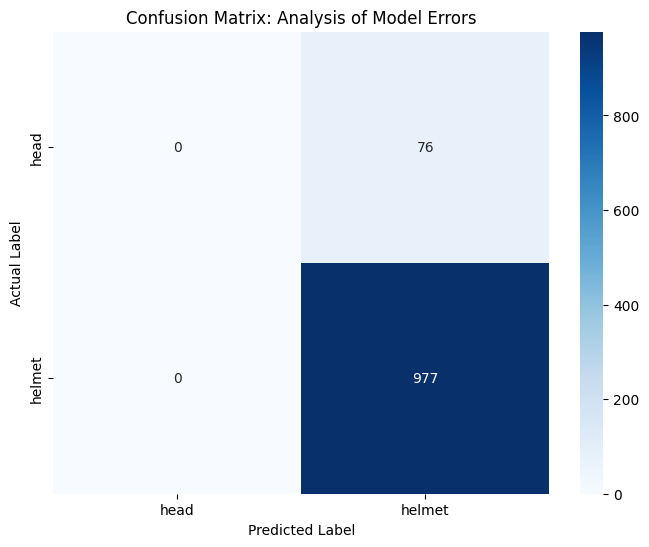


--- Classification Report ---
              precision    recall  f1-score   support

        head       0.00      0.00      0.00        76
      helmet       0.93      1.00      0.96       977

    accuracy                           0.93      1053
   macro avg       0.46      0.50      0.48      1053
weighted avg       0.86      0.93      0.89      1053



c:\Users\Fran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get predictions from validation set
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = val_generator.classes

# 2. Build Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_map.keys(), yticklabels=class_map.keys())
plt.title('Confusion Matrix: Analysis of Model Errors')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=list(class_map.keys())))

In [ ]:
# --- CALCULATING CLASS WEIGHTS ---
# Total samples from your Confusion Matrix (17+59+7+970)
total_samples = 1053 
n_classes = 2

# Number of samples per class
n_head = 76   # (17 + 59)
n_helmet = 977 # (7 + 970)

# Formula: total_samples / (n_classes * n_samples_with_class)
weight_for_head = total_samples / (n_classes * n_head)
weight_for_helmet = total_samples / (n_classes * n_helmet)

class_weight = {0: weight_for_head, 1: weight_for_helmet}

print(f"✅ Weights calculated:")
print(f"Class 0 (Head): {weight_for_head:.2f}")
print(f"Class 1 (Helmet): {weight_for_helmet:.2f}")

✅ Weights calculated:
Class 0 (Head): 6.93
Class 1 (Helmet): 0.54


In [ ]:
history = model.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=class_weight, 
    callbacks=[checkpoint, reduce_lr] 
)

Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.8183 - loss: 0.8715 - val_accuracy: 0.9288 - val_loss: 0.2629 - learning_rate: 1.0000e-05
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 90s 683ms/step - accuracy: 0.6388 - loss: 0.6592 - val_accuracy: 0.8101 - val_loss: 0.4303 - learning_rate: 1.0000e-05
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 96s 724ms/step - accuracy: 0.6086 - loss: 0.6261 - val_accuracy: 0.7426 - val_loss: 0.5160 - learning_rate: 1.0000e-05
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6307 - loss: 0.6386 - val_accuracy: 0.6876 - val_loss: 0.5610 - learning_rate: 1.0000e-05
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 121s 909ms/step - accuracy: 0.6300 - loss: 0.6118 - val_accuracy: 0.6743 - val_loss: 0.5842 - learning_rate: 1.0000e-05
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 98s 740ms/step - accuracy: 0.6340 - loss: 0.6309 - val_accuracy: 0.6676 - val_loss: 0.5738 - learning_rate: 1.0000e-05
Epoch 7/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/s

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get predictions from validation set
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = val_generator.classes

# 2. Build Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_map.keys(), yticklabels=class_map.keys())
plt.title('Confusion Matrix: Analysis of Model Errors')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=list(class_map.keys())))

NameError: name 'val_generator' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step


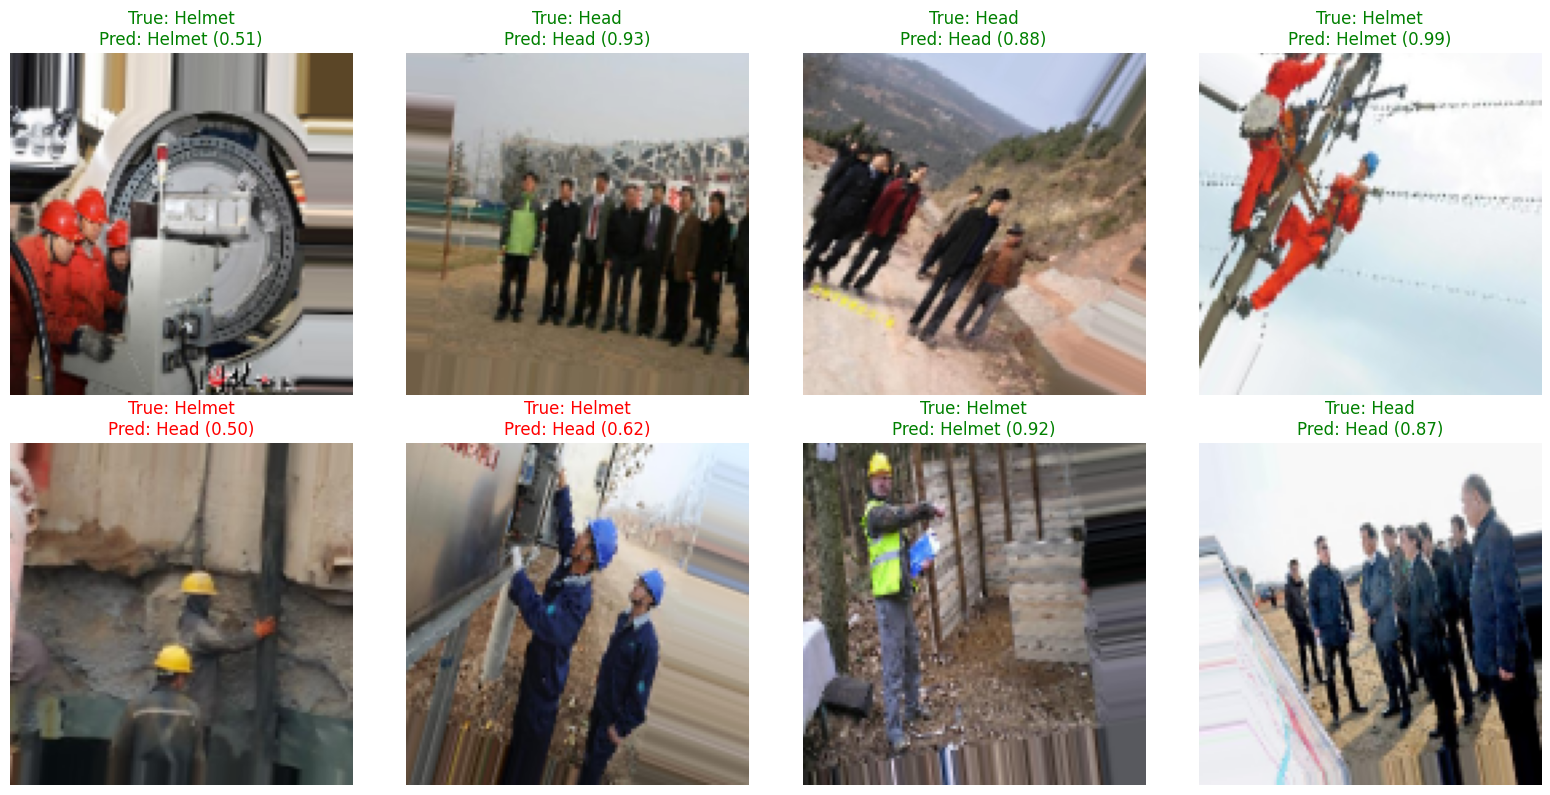

In [ ]:
def plot_sample_predictions(generator, model, num_samples=8):
    images, labels = next(generator)
    preds = model.predict(images)
    
    plt.figure(figsize=(16, 8))
    for i in range(num_samples):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        
        actual = "Helmet" if labels[i] == class_map['helmet'] else "Head"
        predicted = "Helmet" if preds[i] > 0.5 else "Head"
        prob = preds[i][0] if predicted == "Helmet" else 1 - preds[i][0]
        
        color = 'green' if actual == predicted else 'red'
        plt.title(f"True: {actual}\nPred: {predicted} ({prob:.2f})", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_predictions(val_generator, model)

## 6. Deployment-Ready Artifacts

In [ ]:
# To download from Colab
try:
    from google.colab import files
    files.download('../models/best_epi_model.keras')
except:
    print("Running locally. Model saved in the root directory.")

Running locally. Model saved in the root directory.
